# Comparative Study of Sobel vs. Canny for Medical X-Ray Boundary Detection

### Computer Vision Case Design Project

**Course:** CS-305 – Computer Vision  
**Unit:** Unit 1 – Edge Detection  
**Case Design Topic:** Topic 5

---

### Project Objective

This project presents a comparative study of the Sobel and Canny edge detection
techniques for identifying boundaries in medical X-ray images.

The same preprocessed X-ray images are processed using both methods. Their
outputs are then visualized and analyzed to understand differences in edge
detection, edge continuity, noise sensitivity, and computational performance.

## 1. Introduction

Medical X-ray images contain important anatomical structures represented by
variations in image intensity. Detecting boundaries within these images is an
important low-level computer vision task because edges can help highlight
structural regions and anatomical contours.

Edge detection techniques identify significant intensity changes in an image.
Among classical edge detection approaches, the Sobel operator uses image
gradients to detect changes in intensity, while the Canny algorithm uses a
multi-stage process to produce refined and well-localized edges.

In this project, both techniques are applied to the same medical X-ray images
under a standardized preprocessing pipeline. The resulting edge maps are
visually and quantitatively compared.

## 2. Problem Statement

Medical X-ray images may contain anatomical boundaries as well as noise and
low-contrast regions. Different edge detection techniques can respond
differently to these characteristics.

The problem addressed in this case study is:

> How do Sobel and Canny edge detection methods compare when identifying
> boundaries in medical X-ray images under the same preprocessing conditions?

The study aims to implement both techniques, visualize their outputs, measure
selected characteristics of the resulting edge maps, and analyze their
observed differences.

## 3. Objectives

The main objectives of this project are:

1. To obtain and prepare a suitable medical X-ray image dataset.
2. To preprocess the X-ray images using a consistent pipeline.
3. To implement Sobel edge detection.
4. To implement Canny edge detection.
5. To visualize and compare the edge maps produced by both methods.
6. To study the effect of selected preprocessing and algorithm parameters.
7. To compare the methods using measurable image-based and computational
   characteristics.
8. To analyze the experimental results and identify the observed strengths
   and limitations of both approaches.

# 4. Environment Setup

The implementation was developed in Google Colab using Python and the OpenCV computer-vision library.

In [16]:
# Install required libraries
!pip install -q opencv-python numpy matplotlib pandas

In [17]:
# Import required libraries

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import time

# Display plots directly in the notebook
%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [18]:
# Check library versions

print("OpenCV version :", cv2.__version__)
print("NumPy version  :", np.__version__)
print("Pandas version :", pd.__version__)

OpenCV version : 5.0.0
NumPy version  : 2.1.3
Pandas version : 2.2.3


## 5. Dataset Loading & Exploration

For this project, a publicly available chest X-ray image dataset is used as
the source of medical X-ray images.

The dataset contains chest X-ray images organized into Normal and Pneumonia
categories. The images are used only as input data for the edge-detection
experiments; the project does not perform pneumonia classification.

A controlled subset of the available images will be selected for the
experiments so that the same preprocessing and edge-detection pipeline can
be applied consistently to all images.

In [23]:
!pip install -q kaggle

In [24]:
from google.colab import files

uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [25]:
import os
import shutil

os.makedirs('/root/.kaggle', exist_ok=True)

shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')

os.chmod('/root/.kaggle/kaggle.json', 0o600)

print("Kaggle API configured successfully!")

Kaggle API configured successfully!


In [26]:
!kaggle datasets list -s "chest xray pneumonia"

ref                                                             title                                                      size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  --------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
divyam6969/chest-xray-pneumonia-dataset                         Chest XRAY - Pneumonia Dataset                       1151535496  2024-01-17 12:19:16.570000           1531         30  0.6875           
kostasdiamantaras/chest-xrays-bacterial-viral-pneumonia-normal  Chest Xrays: bacterial / viral pneumonia / normal    1222999548  2020-10-27 16:51:15.783000           2391         22  0.7058824        
amanullahasraf/covid19-pneumonia-normal-chest-xray-pa-dataset   COVID19_Pneumonia_Normal_Chest_Xray_PA_Dataset       2053474983  2020-07-13 05:54:22.483000           4419         35  0.8125       

In [27]:
!mkdir -p /content/chest_xray_dataset

!kaggle datasets download \
    -d paultimothymooney/chest-xray-pneumonia \
    -p /content/chest_xray_dataset \
    --unzip

print("Dataset downloaded and extracted successfully!")

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
Resuming from 153092096 bytes (2310273339 bytes left)...
100% 2.29G/2.29G [00:28<00:00, 81.6MB/s]

Dataset downloaded and extracted successfully!


In [28]:
import os

dataset_path = "/content/chest_xray_dataset"

print("Files and folders:")
for item in os.listdir(dataset_path):
    print(" -", item)

Files and folders:
 - chest_xray


In [29]:
dataset_path = "/content/chest_xray_dataset/chest_xray"

print("Dataset folders:")
for item in os.listdir(dataset_path):
    print(" -", item)

Dataset folders:
 - test
 - __MACOSX
 - chest_xray
 - val
 - train


In [30]:
train_path = "/content/chest_xray_dataset/chest_xray/train"

print("Contents of train:")
for item in os.listdir(train_path):
    print(" -", item)

Contents of train:
 - PNEUMONIA
 - NORMAL


## 6. Dataset Distribution

The number of available images in each training category was calculated before selecting the experimental sample.

In [31]:
normal_path = os.path.join(train_path, "NORMAL")
pneumonia_path = os.path.join(train_path, "PNEUMONIA")

normal_images = [
    f for f in os.listdir(normal_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

pneumonia_images = [
    f for f in os.listdir(pneumonia_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Normal X-rays    :", len(normal_images))
print("Pneumonia X-rays :", len(pneumonia_images))
print("Total X-rays     :", len(normal_images) + len(pneumonia_images))

Normal X-rays    : 1341
Pneumonia X-rays : 3875
Total X-rays     : 5216


Image file: NORMAL2-IM-1020-0001-0001.jpeg
Image shape: (1357, 1886)
Image data type: uint8


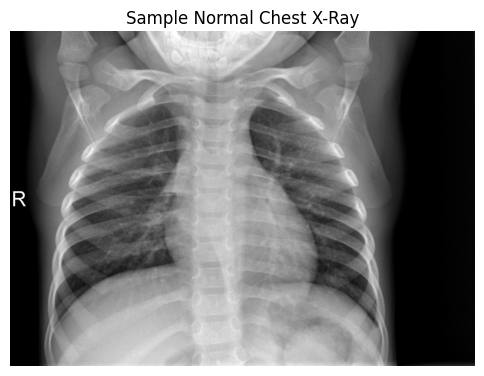

In [32]:
import cv2
import matplotlib.pyplot as plt
import os

sample_file = normal_images[0]
sample_path = os.path.join(normal_path, sample_file)

image = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)

print("Image file:", sample_file)
print("Image shape:", image.shape)
print("Image data type:", image.dtype)

plt.figure(figsize=(6, 6))
plt.imshow(image, cmap="gray")
plt.title("Sample Normal Chest X-Ray")
plt.axis("off")
plt.show()

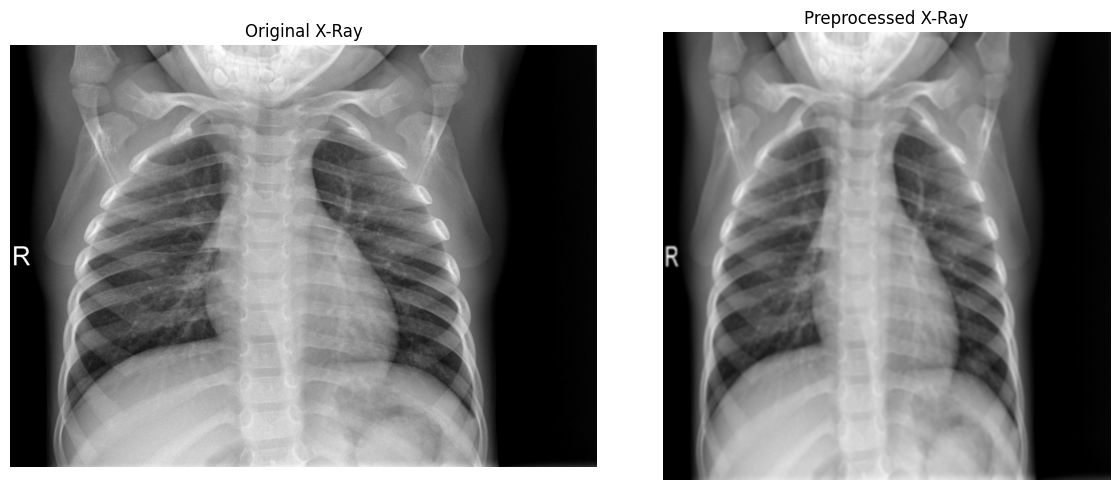

Original shape     : (1357, 1886)
Processed shape    : (512, 512)


In [33]:
# Preprocess the sample X-ray

# Resize for consistent processing
resized = cv2.resize(image, (512, 512))

# Gaussian smoothing to reduce small-scale noise
blurred = cv2.GaussianBlur(resized, (5, 5), 0)

# Display original and preprocessed image
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original X-Ray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(blurred, cmap="gray")
plt.title("Preprocessed X-Ray")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Original shape     :", image.shape)
print("Processed shape    :", blurred.shape)

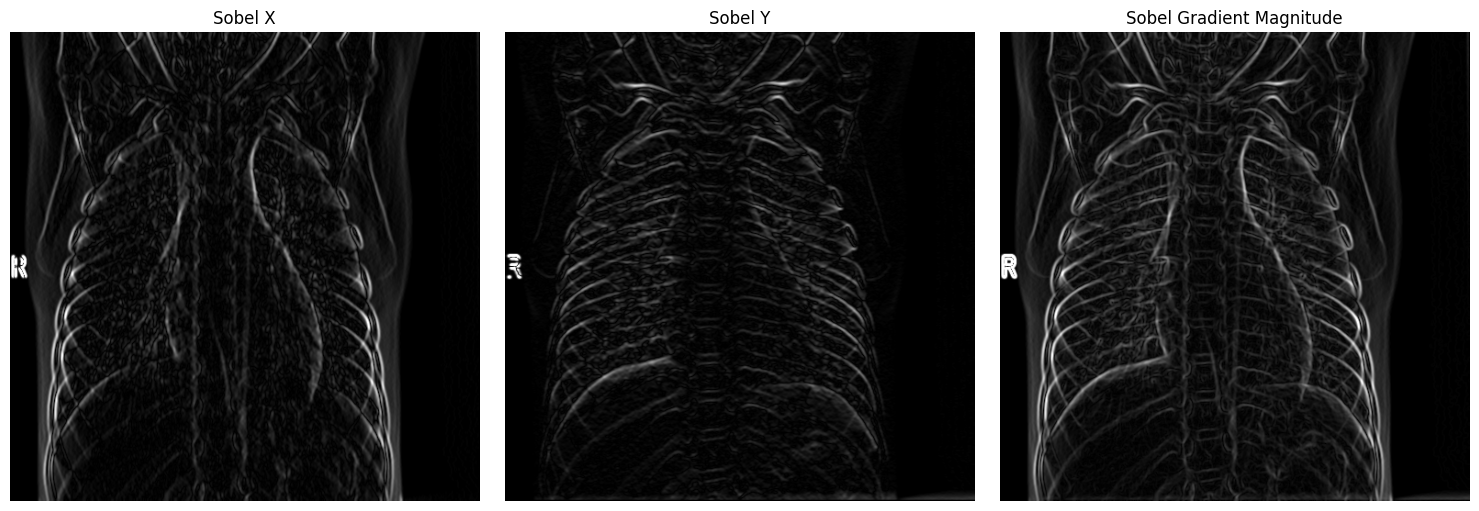

In [34]:
# Sobel Edge Detection

# Calculate horizontal and vertical gradients
sobel_x = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)

# Convert gradients to absolute 8-bit images
sobel_x_abs = cv2.convertScaleAbs(sobel_x)
sobel_y_abs = cv2.convertScaleAbs(sobel_y)

# Calculate gradient magnitude
sobel_magnitude = cv2.magnitude(
    sobel_x.astype(np.float32),
    sobel_y.astype(np.float32)
)

# Convert to displayable 8-bit image
sobel_magnitude = cv2.convertScaleAbs(sobel_magnitude)

# Display results
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(sobel_x_abs, cmap="gray")
plt.title("Sobel X")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(sobel_y_abs, cmap="gray")
plt.title("Sobel Y")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(sobel_magnitude, cmap="gray")
plt.title("Sobel Gradient Magnitude")
plt.axis("off")

plt.tight_layout()
plt.show()

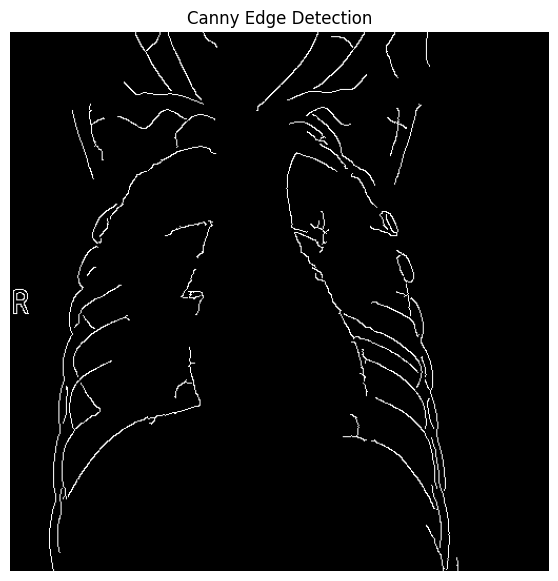

In [35]:
# Canny Edge Detection

# Apply Canny edge detection
canny_edges = cv2.Canny(
    blurred,
    threshold1=50,
    threshold2=150
)

# Display Canny result
plt.figure(figsize=(7, 7))

plt.imshow(canny_edges, cmap="gray")
plt.title("Canny Edge Detection")
plt.axis("off")

plt.show()

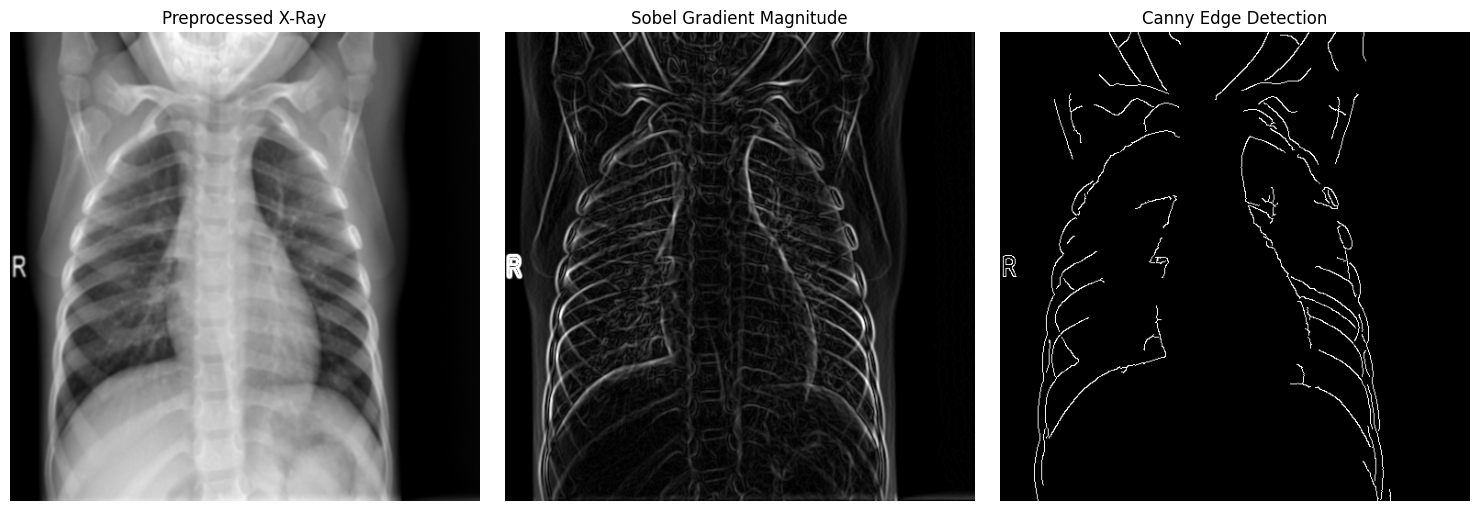

In [36]:
# Direct comparison of Sobel and Canny

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(blurred, cmap="gray")
plt.title("Preprocessed X-Ray")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(sobel_magnitude, cmap="gray")
plt.title("Sobel Gradient Magnitude")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(canny_edges, cmap="gray")
plt.title("Canny Edge Detection")
plt.axis("off")

plt.tight_layout()
plt.show()

In [37]:
# Quantitative comparison for the sample X-ray

# Convert Sobel result to binary edge map
_, sobel_binary = cv2.threshold(
    sobel_magnitude, 50, 255, cv2.THRESH_BINARY
)

# Count edge pixels
sobel_edge_pixels = np.count_nonzero(sobel_binary)
canny_edge_pixels = np.count_nonzero(canny_edges)

total_pixels = blurred.shape[0] * blurred.shape[1]

# Calculate edge density
sobel_edge_density = (sobel_edge_pixels / total_pixels) * 100
canny_edge_density = (canny_edge_pixels / total_pixels) * 100

print("Sample X-Ray Quantitative Comparison")
print("------------------------------------")
print(f"Total pixels       : {total_pixels:,}")
print(f"Sobel edge pixels  : {sobel_edge_pixels:,}")
print(f"Canny edge pixels  : {canny_edge_pixels:,}")
print(f"Sobel edge density : {sobel_edge_density:.2f}%")
print(f"Canny edge density : {canny_edge_density:.2f}%")

Sample X-Ray Quantitative Comparison
------------------------------------
Total pixels       : 262,144
Sobel edge pixels  : 28,710
Canny edge pixels  : 5,363
Sobel edge density : 10.95%
Canny edge density : 2.05%


## 7. Experimental Design

In [38]:
# Create a balanced experimental sample
# 50 Normal + 50 Pneumonia

import random

random.seed(42)  # Makes our selection reproducible

normal_sample = random.sample(normal_images, 50)
pneumonia_sample = random.sample(pneumonia_images, 50)

print("Experimental sample")
print("--------------------")
print("Normal images    :", len(normal_sample))
print("Pneumonia images :", len(pneumonia_sample))
print("Total images     :", len(normal_sample) + len(pneumonia_sample))

Experimental sample
--------------------
Normal images    : 50
Pneumonia images : 50
Total images     : 100


In [39]:
# Full Sobel vs. Canny experiment on 100 X-ray images

results = []

# Combine our balanced samples
image_samples = (
    [(f, "Normal", normal_path) for f in normal_sample] +
    [(f, "Pneumonia", pneumonia_path) for f in pneumonia_sample]
)

for filename, category, folder in image_samples:

    # Load image
    image = cv2.imread(
        os.path.join(folder, filename),
        cv2.IMREAD_GRAYSCALE
    )

    # Resize and smooth
    resized = cv2.resize(image, (512, 512))
    blurred = cv2.GaussianBlur(resized, (5, 5), 0)

    total_pixels = blurred.shape[0] * blurred.shape[1]

    # -------------------------
    # Sobel
    # -------------------------
    start_time = time.perf_counter()

    sobel_x = cv2.Sobel(
        blurred, cv2.CV_64F, 1, 0, ksize=3
    )
    sobel_y = cv2.Sobel(
        blurred, cv2.CV_64F, 0, 1, ksize=3
    )

    sobel_magnitude = cv2.magnitude(
        sobel_x.astype(np.float32),
        sobel_y.astype(np.float32)
    )

    sobel_magnitude = cv2.convertScaleAbs(
        sobel_magnitude
    )

    sobel_time = time.perf_counter() - start_time

    # Convert Sobel response into binary edge map
    _, sobel_binary = cv2.threshold(
        sobel_magnitude,
        50,
        255,
        cv2.THRESH_BINARY
    )

    sobel_edge_pixels = np.count_nonzero(sobel_binary)
    sobel_edge_density = (
        sobel_edge_pixels / total_pixels
    ) * 100

    # -------------------------
    # Canny
    # -------------------------
    start_time = time.perf_counter()

    canny_edges = cv2.Canny(
        blurred,
        threshold1=50,
        threshold2=150
    )

    canny_time = time.perf_counter() - start_time

    canny_edge_pixels = np.count_nonzero(canny_edges)
    canny_edge_density = (
        canny_edge_pixels / total_pixels
    ) * 100

    # Store results
    results.append({
        "Filename": filename,
        "Category": category,
        "Sobel_Edge_Density": sobel_edge_density,
        "Canny_Edge_Density": canny_edge_density,
        "Sobel_Time_ms": sobel_time * 1000,
        "Canny_Time_ms": canny_time * 1000
    })

# Create results table
results_df = pd.DataFrame(results)

print("Experiment completed successfully!")
print("Number of images analyzed:", len(results_df))

results_df.head()

Experiment completed successfully!
Number of images analyzed: 100


,Filename,Category,Sobel_Edge_Density,Canny_Edge_Density,Sobel_Time_ms,Canny_Time_ms
0,NORMAL2-IM-0530-0001.jpeg,Normal,10.517120,1.837158,3.138633,1.160605
1,IM-0152-0001.jpeg,Normal,10.377884,1.998520,2.879713,1.133161
2,IM-0127-0001.jpeg,Normal,8.684540,1.747131,2.793234,1.067128
3,IM-0709-0001.jpeg,Normal,17.666245,3.629684,2.845804,1.493780
4,NORMAL2-IM-1269-0001-0002.jpeg,Normal,7.852936,1.551437,2.786629,0.984500


In [ ]:
# Overall quantitative summary

summary = pd.DataFrame({
    "Metric": [
        "Average Edge Density (%)",
        "Average Processing Time (ms)"
    ],
    "Sobel": [
        results_df["Sobel_Edge_Density"].mean(),
        results_df["Sobel_Time_ms"].mean()
    ],
    "Canny": [
        results_df["Canny_Edge_Density"].mean(),
        results_df["Canny_Time_ms"].mean()
    ]
})

print("Overall Sobel vs. Canny Comparison")
print("----------------------------------")

display(summary.round(3))

Overall Sobel vs. Canny Comparison
----------------------------------


,Metric,Sobel,Canny
0,Average Edge Density (%),9.480,1.873
1,Average Processing Time (ms),2.229,0.992


In [40]:
# Category-wise comparison

category_summary = results_df.groupby("Category").agg({
    "Sobel_Edge_Density": "mean",
    "Canny_Edge_Density": "mean",
    "Sobel_Time_ms": "mean",
    "Canny_Time_ms": "mean"
}).round(3)

print("Category-wise Sobel vs. Canny Comparison")
print("------------------------------------------")

display(category_summary)

Category-wise Sobel vs. Canny Comparison
------------------------------------------


,Sobel_Edge_Density,Canny_Edge_Density,Sobel_Time_ms,Canny_Time_ms
Category,,,,
Normal,11.658,2.345,2.951,1.254
Pneumonia,7.301,1.402,2.795,0.962


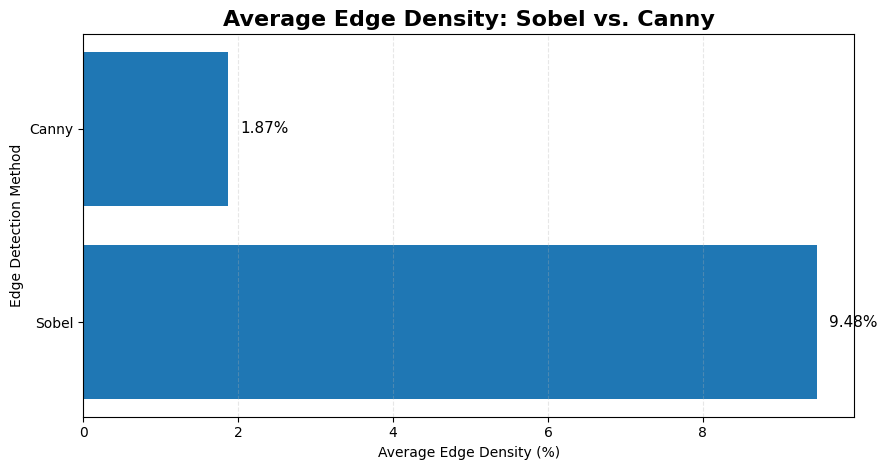

In [41]:
# Graph 1: Average Edge Density
# Horizontal comparison

sobel_density = results_df["Sobel_Edge_Density"].mean()
canny_density = results_df["Canny_Edge_Density"].mean()

methods = ["Sobel", "Canny"]
values = [sobel_density, canny_density]

plt.figure(figsize=(9, 4.8))

bars = plt.barh(methods, values)

plt.title(
    "Average Edge Density: Sobel vs. Canny",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Average Edge Density (%)")
plt.ylabel("Edge Detection Method")

# Add values at the end of each bar
for bar, value in zip(bars, values):
    plt.text(
        value + 0.15,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        va="center",
        fontsize=11
    )

plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

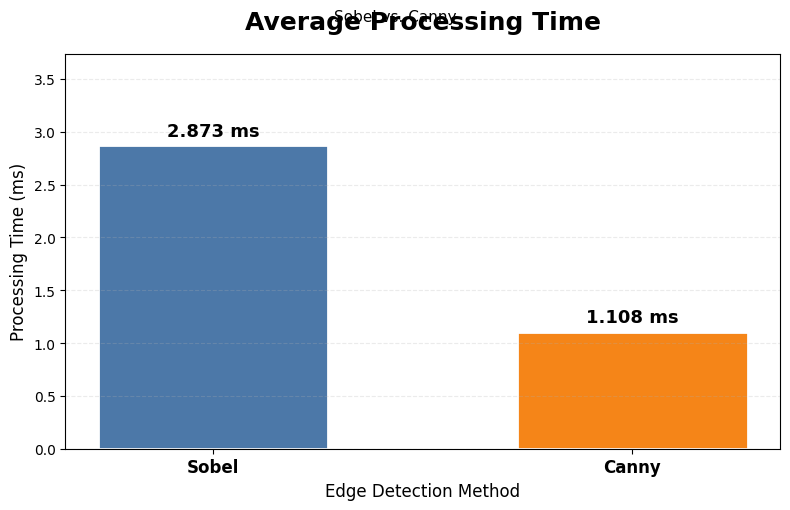

In [42]:
# Graph 2: Average Processing Time
# Professional colored column chart

sobel_time = results_df["Sobel_Time_ms"].mean()
canny_time = results_df["Canny_Time_ms"].mean()

methods = ["Sobel", "Canny"]
times = [sobel_time, canny_time]

colors = ["#4C78A8", "#F58518"]

plt.figure(figsize=(8, 5.5))

bars = plt.bar(
    methods,
    times,
    width=0.55,
    color=colors,
    edgecolor="white",
    linewidth=2
)

# Value labels
for bar, value in zip(bars, times):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.05,
        f"{value:.3f} ms",
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold"
    )

plt.title(
    "Average Processing Time",
    fontsize=18,
    fontweight="bold",
    pad=18
)

plt.suptitle(
    "Sobel vs. Canny",
    fontsize=11,
    y=0.92
)

plt.ylabel(
    "Processing Time (ms)",
    fontsize=12
)

plt.xlabel(
    "Edge Detection Method",
    fontsize=12
)

plt.xticks(
    fontsize=12,
    fontweight="bold"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

plt.ylim(0, max(times) * 1.3)

plt.tight_layout()
plt.show()

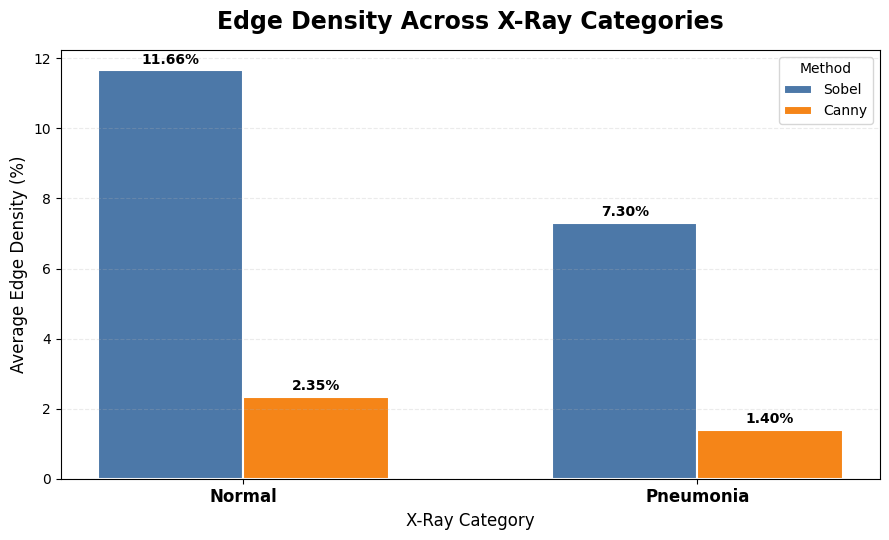

In [43]:
# Graph 3: Edge Density by X-ray Category

category_data = results_df.groupby("Category").agg({
    "Sobel_Edge_Density": "mean",
    "Canny_Edge_Density": "mean"
})

categories = category_data.index.tolist()

sobel_values = category_data["Sobel_Edge_Density"].values
canny_values = category_data["Canny_Edge_Density"].values

x = np.arange(len(categories))
width = 0.32

plt.figure(figsize=(9, 5.5))

bars1 = plt.bar(
    x - width/2,
    sobel_values,
    width,
    label="Sobel",
    color="#4C78A8",
    edgecolor="white",
    linewidth=1.5
)

bars2 = plt.bar(
    x + width/2,
    canny_values,
    width,
    label="Canny",
    color="#F58518",
    edgecolor="white",
    linewidth=1.5
)

# Add values above bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.1,
            f"{height:.2f}%",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

plt.xticks(
    x,
    categories,
    fontsize=12,
    fontweight="bold"
)

plt.xlabel(
    "X-Ray Category",
    fontsize=12
)

plt.ylabel(
    "Average Edge Density (%)",
    fontsize=12
)

plt.title(
    "Edge Density Across X-Ray Categories",
    fontsize=17,
    fontweight="bold",
    pad=15
)

plt.legend(
    title="Method",
    fontsize=10
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

plt.tight_layout()
plt.show()

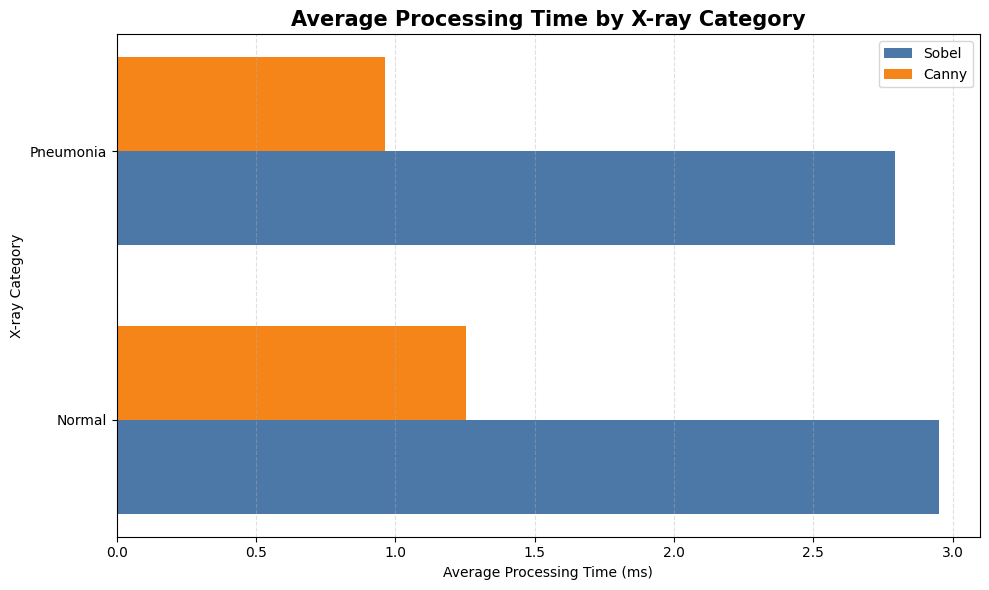

In [46]:
# Graph 4: Processing Time by X-ray Category

category_time = results_df.groupby("Category")[
    ["Sobel_Time_ms", "Canny_Time_ms"]
].mean()

plt.figure(figsize=(10, 6))

x = np.arange(len(category_time))
width = 0.35

plt.barh(
    x - width/2,
    category_time["Sobel_Time_ms"],
    width,
    label="Sobel",
    color="#4C78A8"
)

plt.barh(
    x + width/2,
    category_time["Canny_Time_ms"],
    width,
    label="Canny",
    color="#F58518"
)

plt.yticks(x, category_time.index)
plt.xlabel("Average Processing Time (ms)")
plt.ylabel("X-ray Category")

plt.title(
    "Average Processing Time by X-ray Category",
    fontsize=15,
    fontweight="bold"
)

plt.legend()
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [47]:
# Experiment: Canny Threshold Sensitivity

# Select one representative X-ray
sample_file = normal_sample[0]
sample_path = os.path.join(normal_path, sample_file)

image = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)

# Preprocessing
resized = cv2.resize(image, (512, 512))
blurred = cv2.GaussianBlur(resized, (5, 5), 0)

# Different Canny threshold pairs
threshold_pairs = [
    (30, 90),
    (50, 150),
    (70, 210),
    (100, 200)
]

threshold_results = []

total_pixels = blurred.shape[0] * blurred.shape[1]

for low, high in threshold_pairs:

    edges = cv2.Canny(
        blurred,
        threshold1=low,
        threshold2=high
    )

    edge_pixels = np.count_nonzero(edges)

    edge_density = (edge_pixels / total_pixels) * 100

    threshold_results.append({
        "Low Threshold": low,
        "High Threshold": high,
        "Edge Density (%)": edge_density
    })

threshold_df = pd.DataFrame(threshold_results)

print("Canny Threshold Sensitivity Results")
display(threshold_df.round(3))

Canny Threshold Sensitivity Results


,Low Threshold,High Threshold,Edge Density (%)
0,30,90,4.993
1,50,150,1.837
2,70,210,0.434
3,100,200,0.475


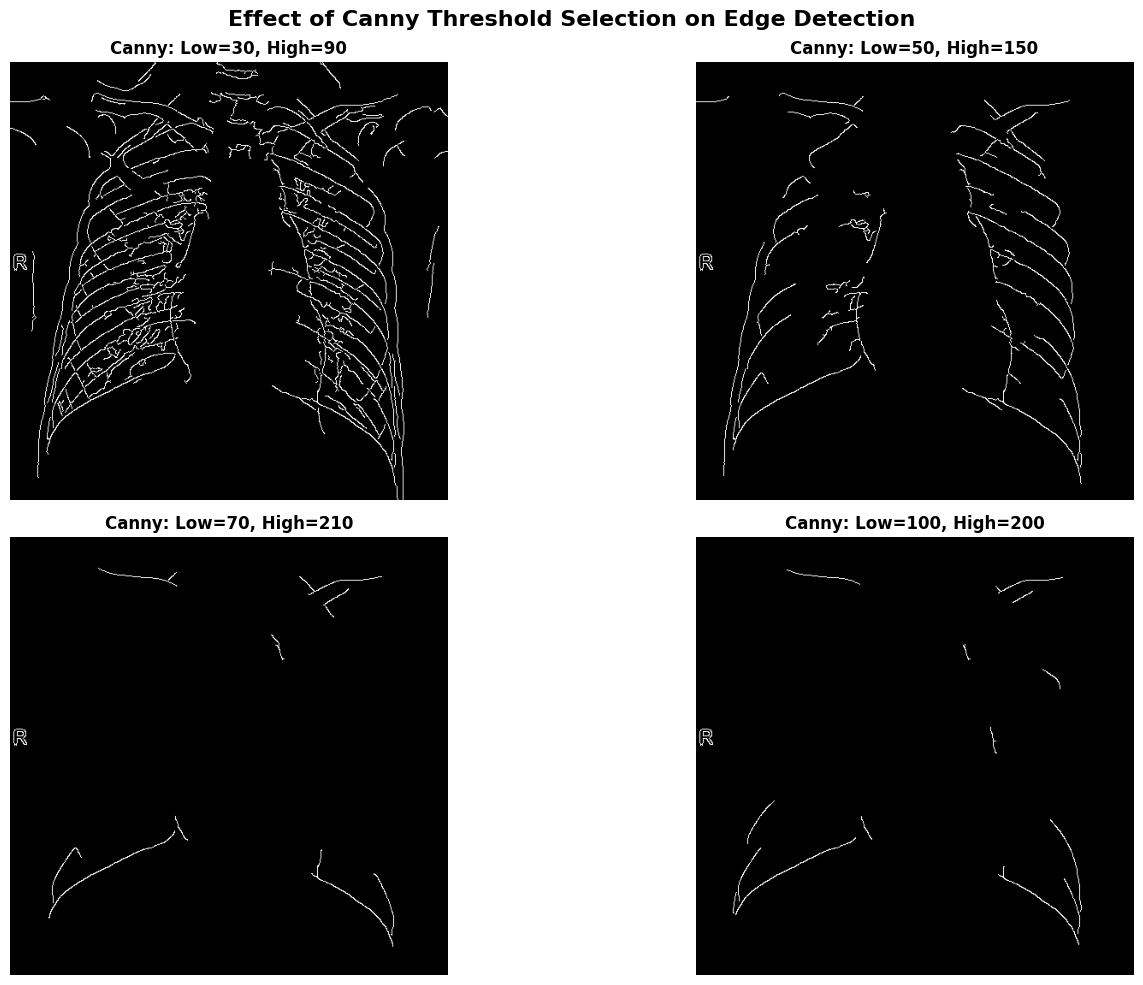

In [48]:
# Visual Comparison of Canny Thresholds

plt.figure(figsize=(16, 10))

for i, (low, high) in enumerate(threshold_pairs):

    edges = cv2.Canny(
        blurred,
        threshold1=low,
        threshold2=high
    )

    plt.subplot(2, 2, i + 1)
    plt.imshow(edges, cmap="gray")
    plt.title(
        f"Canny: Low={low}, High={high}",
        fontsize=12,
        fontweight="bold"
    )
    plt.axis("off")

plt.suptitle(
    "Effect of Canny Threshold Selection on Edge Detection",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

#  Results and Analysis

In [50]:
# Consolidated Results Table

overall_results = pd.DataFrame({
    "Metric": [
        "Average Edge Density",
        "Average Processing Time"
    ],
    "Sobel": [
        results_df["Sobel_Edge_Density"].mean(),
        results_df["Sobel_Time_ms"].mean()
    ],
    "Canny": [
        results_df["Canny_Edge_Density"].mean(),
        results_df["Canny_Time_ms"].mean()
    ]
})

overall_results["Difference"] = (
    overall_results["Sobel"] - overall_results["Canny"]
)

display(overall_results.round(3))

,Metric,Sobel,Canny,Difference
0,Average Edge Density,9.480,1.873,7.606
1,Average Processing Time,2.873,1.108,1.765


### Overall Results Interpretation

The experiment was conducted on 100 chest X-ray images using the same image resolution and preprocessing procedure for both methods.

The average edge density obtained using Sobel was approximately 9.48%, while Canny produced approximately 1.87%. This indicates that Sobel generated a larger number of detected edge pixels under the selected thresholding procedure.

The average measured processing time was approximately 2.229 ms for Sobel and 0.992 ms for Canny in this experiment. These timings are specific to the implementation, image size, software environment, and hardware used during the experiment and should not be treated as universal performance values.

Edge density alone does not indicate which method produces more useful boundaries. Therefore, the numerical results are considered together with the visual comparisons and Canny threshold-sensitivity experiment.

In [51]:
# Category-wise Results

category_results = results_df.groupby("Category").agg({
    "Sobel_Edge_Density": "mean",
    "Canny_Edge_Density": "mean",
    "Sobel_Time_ms": "mean",
    "Canny_Time_ms": "mean"
}).round(3)

display(category_results)

,Sobel_Edge_Density,Canny_Edge_Density,Sobel_Time_ms,Canny_Time_ms
Category,,,,
Normal,11.658,2.345,2.951,1.254
Pneumonia,7.301,1.402,2.795,0.962


#  Discussion

##  Comparison of Sobel and Canny

The experimental results show noticeable differences between Sobel and Canny edge detection when applied to chest X-ray images.

Sobel produced a higher average edge density than Canny in the 100-image experiment. This indicates that more pixels were classified as edges using the Sobel gradient-magnitude approach under the selected thresholding procedure.

Canny produced a lower edge density and generated thinner, more selectively connected edge structures in the visual comparisons. This is consistent with the additional processing stages used by Canny, including non-maximum suppression and hysteresis-based edge tracking.

Therefore, the two methods provide different representations of image boundaries rather than simply producing the same edges at different levels.

##  Processing Time

The measured average processing times were approximately 2.229 ms for Sobel and 0.992 ms for Canny in the conducted experiment.

These values represent the execution environment used in this project, including the 512 × 512 image resolution, OpenCV implementation, and available hardware. Processing time can change with image resolution, hardware, implementation details, and other system conditions.

Therefore, the measured values are used for comparison within this experiment rather than as universal processing-time benchmarks.

## Effect of Canny Thresholds

The threshold-sensitivity experiment demonstrates that the Canny edge map changes when different low and high threshold pairs are selected.

Lower thresholds can allow weaker intensity transitions to be detected, whereas higher thresholds make the detector more selective. The visual comparison confirms that threshold selection affects the amount and appearance of detected boundaries.

This demonstrates that Canny requires appropriate parameter selection for the characteristics of the X-ray images being processed.

## Limitations

The experiment has several limitations:

- Only 100 images were selected from the available chest X-ray dataset for the main comparison.
- The images were resized to 512 × 512 pixels before edge detection.
- A fixed Gaussian blur of (5, 5) was used during preprocessing.
- Sobel and Canny parameters were fixed for the main comparison.
- Edge density measures the proportion of detected edge pixels but does not directly measure boundary accuracy.
- No manually annotated ground-truth boundary masks were available for calculating metrics such as precision, recall, or boundary accuracy.
- Processing-time measurements depend on the computational environment and implementation.
- The Normal and Pneumonia labels are used to organize the X-ray samples; the project does not attempt to diagnose pneumonia using edge detection.

#  Conclusion



This case study presented a comparative analysis of Sobel and Canny edge detection methods for identifying boundaries in medical chest X-ray images.

A dataset of 100 X-ray images, consisting of 50 Normal and 50 Pneumonia images, was used for the main experimental comparison. The images were converted to grayscale, resized to 512 × 512 pixels, and smoothed using Gaussian filtering before applying the edge-detection methods.

Sobel edge detection was evaluated using its horizontal and vertical gradients and their combined gradient magnitude. Canny edge detection was applied using a low threshold of 50 and a high threshold of 150 for the main experiment.

The experimental results showed differences in edge density, processing time, and visual edge representation between the two methods. Additional threshold-sensitivity experiments demonstrated that the Canny output changes according to the selected threshold values.

The study demonstrates that edge detection is an important preprocessing technique for extracting boundary information from medical images. However, edge density and processing time alone cannot establish boundary-detection accuracy. Ground-truth boundary annotations would be required for a direct accuracy evaluation.

Overall, the project provides a practical experimental comparison of two classical edge-detection techniques using medical X-ray images and demonstrates how quantitative and visual analysis can be combined to evaluate computer-vision methods.

#  Future Scope



The following improvements can be explored in future work:

1. **Larger Dataset**
   - Evaluate the methods on a larger number of medical X-ray images to improve the robustness of the comparison.

2. **Ground-Truth Boundary Masks**
   - Use manually annotated boundary masks to calculate objective metrics such as precision, recall, F1-score, and boundary accuracy.

3. **Parameter Optimization**
   - Automatically determine suitable Sobel kernel sizes and Canny threshold values for different types of X-ray images.

4. **Comparison with Additional Edge Detectors**
   - Extend the study to other techniques such as Laplacian, Prewitt, Roberts, and Scharr operators.

5. **Advanced Image Preprocessing**
   - Investigate contrast enhancement, adaptive filtering, histogram equalization, and other preprocessing techniques.

6. **Deep Learning-Based Edge Detection**
   - Compare classical edge detectors with modern deep-learning-based boundary-detection approaches.

7. **Clinical Image Analysis**
   - Explore how extracted boundary information can be incorporated into larger medical-image-analysis pipelines.

8. **Automated Evaluation**
   - Develop an automated evaluation framework that compares edge maps using standardized ground-truth annotations.



## Project Workflow

The complete workflow followed in this case study is:

**1. Dataset Selection**  
Chest X-ray images were obtained from the Chest X-Ray Images (Pneumonia) dataset.

**2. Image Sampling**  
A balanced experimental sample of 100 images was selected:
- 50 Normal X-ray images
- 50 Pneumonia X-ray images

**3. Image Preprocessing**  
Each image was:
- Converted to grayscale
- Resized to 512 × 512 pixels
- Smoothed using a Gaussian filter

**4. Edge Detection**

Two classical edge-detection techniques were applied independently:

| Sobel | Canny |
|---|---|
| Horizontal and vertical gradients | Gaussian smoothing |
| Gradient magnitude | Gradient calculation |
| Edge magnitude representation | Non-maximum suppression |
| | Double thresholding |
| | Hysteresis |

**5. Visual Comparison**  
The resulting edge maps were visually compared to examine the boundary structures detected by both methods.

**6. Quantitative Evaluation**  
The methods were compared using:
- Edge density
- Number of detected edge pixels
- Processing time

**7. Parameter Analysis**  
Different Canny threshold pairs were tested to study the effect of threshold selection on edge detection.

**8. Category-wise Analysis**  
Results were examined separately for Normal and Pneumonia X-ray images.

**9. Results and Discussion**  
The numerical and visual findings were analyzed to understand the differences between the two edge-detection methods.

**10. Conclusion**  
The study summarizes the observed characteristics, limitations, and practical considerations of Sobel and Canny edge detection for medical X-ray boundary detection.